# 🔍 RAG Retrieval Evaluation

Comprehensive evaluation of retrieval performance with popularity bias analysis.

---

## 📋 Prerequisites

Run `rag_indexing.ipynb` first to create the index.

---

## 🎯 Evaluation Pipeline

1. **Load Data** - Questions from popularity-enriched QA datasets
2. **Run Retrieval** - Retrieve documents and compute core metrics
3. **Analyze Performance** - Recall@K, MRR, ranking metrics
4. **Bias Analysis** - Popularity bias and fairness metrics
5. **Visualizations** - Comprehensive visual analysis

---

## 📊 Key Metrics

- **Recall@K** - Percentage of questions where correct document is in top K
- **MRR** (Mean Reciprocal Rank) - Average of 1/rank for all questions
- **Popularity Bias** - Preference for popular documents over correct ones
- **Decile Analysis** - Performance breakdown by popularity bins

## 1️⃣ Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from tqdm import tqdm
from datasets import load_dataset

from config import DATA_DIR, CACHE_DIR
from rag.native_rag_service import nativeRagService, IndexingConfig

# Evaluation Configuration
TOP_K = 10
K_VALUES = [1, 3, 5, 10]
MAX_K = 10

# Collection & Index
RUN_NAME = "wiki_200k_balanced_qa_s_250_only"
COLLECTION_NAME = "native_rag"
COLLECTION_ROOT = Path(DATA_DIR) / RUN_NAME
INDEX_DIR = COLLECTION_ROOT / "index"
PATH_TO_QA_DATA = COLLECTION_ROOT / "train_questions.parquet"

# Embedding Configuration (MUST match indexing settings exactly!)
# Note: Chunk size was 1000 during indexing, not 4000
CHUNK_SIZE = 1000  # Fixed: was 4000, should match rag_indexing.ipynb
CHUNK_OVERLAP = 100  # Fixed: was 200, should match rag_indexing.ipynb
EMBEDDING_PROVIDER = "huggingface"
EMBEDDING_MODEL = "intfloat/multilingual-e5-small"

print("✓ Configuration loaded")
print(f"  Note: E5 model detected - query/passage prefixes will be auto-applied")

✓ Configuration loaded
  Note: E5 model detected - query/passage prefixes will be auto-applied


## 2️⃣ Load Data & Index

In [ ]:
# Load questions
print(f"Loading questions from {PATH_TO_QA_DATA}")
qa_df = pd.read_parquet(PATH_TO_QA_DATA)

# Drop rows without valid question text
initial_len = len(qa_df)
qa_df = qa_df.dropna(subset=["question_text"])
qa_df = qa_df[qa_df["question_text"].str.strip().str.len() > 0]
if len(qa_df) < initial_len:
    print(f"⚠️ Dropped {initial_len - len(qa_df)} rows with missing/invalid question text")

# Normalize Wikipedia IDs to string format for matching
qa_df['wikipedia_id'] = qa_df['wikipedia_id'].astype(str).str.strip()

print(f"✓ Loaded {len(qa_df):,} questions")

if 'dataset' in qa_df.columns:
    print(f"  📚 Datasets: {qa_df['dataset'].value_counts().to_dict()}")
    
if 'is_synthetic' in qa_df.columns:
    n_synthetic = int(qa_df['is_synthetic'].sum())
    n_real = len(qa_df) - n_synthetic
    print(f"  🤖 Real: {n_real:,} | Synthetic: {n_synthetic:,}")

# Display sample
sample = qa_df.iloc[0]
print(f"\n  Sample: {sample['question_text'][:80]}...")
print(f"  Answer: {sample['answers']}")
print(f"  Wiki ID: {sample['wikipedia_id']}")

Loading questions from /Users/cyro/Documents/VSC/PopularityBias/data/wiki_200k_balanced_qa_s_250_only/train_questions.parquet
✓ Loaded 2,500 questions
  📚 Datasets: {'synthetic': 2500}
  🤖 Real: 0 | Synthetic: 2,500

  Sample: What family does the moth Persicoptila phoenoxantha belong to?...
  Answer: None
  Wiki ID: 42837062


In [41]:
# Load RAG index
print(f"Loading index from {INDEX_DIR}")
service = nativeRagService(IndexingConfig(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    embedding_provider=EMBEDDING_PROVIDER,
    embedding_model=EMBEDDING_MODEL,
))

index = service.load_index(output_dir=INDEX_DIR, collection_name=COLLECTION_NAME)
if index is None:
    raise RuntimeError(f"Index not found at {INDEX_DIR}. Run rag_indexing.ipynb first.")

num_chunks = index._collection.count()
print(f"✓ Loaded index with {num_chunks:,} chunks")

Use pytorch device_name: mps
Load pretrained SentenceTransformer: intfloat/multilingual-e5-small


Loading index from /Users/cyro/Documents/VSC/PopularityBias/data/wiki_200k_balanced_qa_s_250_only/index


Loaded index with cosine distance


✓ Loaded index with 1,709,721 chunks


In [42]:
# Load corpus popularity for decile calculation
print(f"Loading corpus popularity distribution")
pop_ds = load_dataset("Cyro1/enwiki_pageviews_m", split="train+test", cache_dir=CACHE_DIR)

corpus_pops = []
for i in tqdm(range(0, len(pop_ds), 100_000), desc="Extracting popularity"):
    corpus_pops.extend(pop_ds[i : i + 100_000]["popularity_avg"])

_, corpus_bin_edges = pd.qcut(pd.Series(corpus_pops), q=10, retbins=True, duplicates='drop')
print(f"✓ Loaded {len(corpus_pops):,} popularity scores and computed deciles")

Loading corpus popularity distribution


Extracting popularity: 100%|██████████| 60/60 [00:05<00:00, 10.95it/s]


✓ Loaded 5,903,530 popularity scores and computed deciles


## 3️⃣ Run Evaluation

In [43]:
print(f"\n{'='*70}")
print(f"Running Evaluation on {len(qa_df):,} questions")
print(f"{'='*70}")

# 1. Retrieve top-k for each metric (no evaluation in service)
results_df = service.retrieve_topk_by_metric(
    index=index,
    questions=qa_df["question_text"].tolist(),
    expected_ids=qa_df["wikipedia_id"].astype(str).tolist(),
    top_k=MAX_K,
    metrics=["cosine"],
    batch_size=64
)

# 2. Merge Metadata (Popularity, Origin, etc.)
meta_df = qa_df.copy()
meta_df = meta_df.rename(columns={"question_text": "question", "popularity_avg": "popularity"})
join_cols = ["question", "wikipedia_id"]

results_df = results_df.merge(
    meta_df[[c for c in meta_df.columns if c in ["popularity", "is_synthetic", "dataset", "wikipedia_title"] + join_cols]],
    on=join_cols,
    how="left"
)

# 3. Compute evaluation fields from top-k

def _compute_eval(row):
    topk_ids = row.get("topk_ids") or []
    topk_scores = row.get("topk_scores") or []
    topk_pops = row.get("topk_popularities") or []
    expected = row.get("wikipedia_id", "")

    found_at_rank = None
    correct_score = None
    wrong_pops = []

    for idx, doc_id in enumerate(topk_ids, 1):
        if doc_id == expected and found_at_rank is None:
            found_at_rank = idx
            if idx - 1 < len(topk_scores):
                correct_score = topk_scores[idx - 1]
        else:
            if idx - 1 < len(topk_pops):
                pop = topk_pops[idx - 1]
                if pop is not None:
                    wrong_pops.append(pop)

    return pd.Series({
        "found_at_rank": found_at_rank,
        "correct_doc_score": correct_score,
        "wrong_docs_popularities": wrong_pops,
    })

results_df = pd.concat([results_df, results_df.apply(_compute_eval, axis=1)], axis=1)

# 4. Add Popularity Deciles
results_df['pop_decile'] = pd.cut(
    results_df['popularity'].fillna(0),
    bins=corpus_bin_edges,
    labels=False,
    include_lowest=True
).fillna(0).astype(int)

print(f"✓ Results computed: {len(results_df):,} rows (metrics: {results_df['metric'].unique()})")
print(results_df[["metric", "found_at_rank"]].groupby("metric").describe())


Running Evaluation on 2,500 questions


Evaluating (cosine): 100%|██████████| 40/40 [00:45<00:00,  1.13s/batch]


✓ Results computed: 2,500 rows (metrics: ['cosine'])
       found_at_rank                                             
               count      mean      std  min  25%  50%  75%   max
metric                                                           
cosine        2150.0  1.073023  0.53432  1.0  1.0  1.0  1.0  10.0


In [44]:
# Diagnostics: missing popularity + decile mismatch vs indexing
print("\nDecile diagnostics")

# 1) Missing popularity in evaluation
if "popularity" in results_df.columns:
    missing_pop = results_df["popularity"].isna().sum()
    print(f"Missing popularity: {missing_pop:,} / {len(results_df):,} ({missing_pop/len(results_df):.2%})")
else:
    print("No 'popularity' column in results_df")

# 2) Distribution in evaluation (computed from corpus bins)
if "pop_decile" in results_df.columns:
    eval_dist = results_df["pop_decile"].value_counts(normalize=True).sort_index()
    print("\nEvaluation pop_decile distribution (%):")
    print((eval_dist * 100).round(2))

# 3) Distribution from indexing (if decile exists in qa_df)
if "decile" in qa_df.columns:
    idx_dist = qa_df["decile"].value_counts(normalize=True).sort_index()
    print("\nIndexing decile distribution (%):")
    print((idx_dist * 100).round(2))

    # Compare alignment for matched questions
    if "question_text" in qa_df.columns and "question" in results_df.columns:
        merged = results_df.merge(
            qa_df[["question_text", "wikipedia_id", "decile"]],
            left_on=["question", "wikipedia_id"],
            right_on=["question_text", "wikipedia_id"],
            how="left"
        )
        if "decile" in merged.columns and "pop_decile" in merged.columns:
            mismatch = (merged["decile"].notna()) & (merged["decile"] != merged["pop_decile"])
            mism_count = mismatch.sum()
            total = merged["decile"].notna().sum()
            print(f"\nDecile mismatch (indexing vs evaluation): {mism_count:,} / {total:,} ({(mism_count/total if total else 0):.2%})")
else:
    print("\nNo 'decile' column in qa_df (indexing distribution not available)")


Decile diagnostics
Missing popularity: 0 / 2,500 (0.00%)

Evaluation pop_decile distribution (%):
pop_decile
0    10.08
1     9.92
2    10.00
3    10.00
4    10.00
5    10.00
6    10.00
7    10.00
8    10.00
9    10.00
Name: proportion, dtype: float64

Indexing decile distribution (%):
decile
0    10.0
1    10.0
2    10.0
3    10.0
4    10.0
5    10.0
6    10.0
7    10.0
8    10.0
9    10.0
Name: proportion, dtype: float64

Decile mismatch (indexing vs evaluation): 2 / 2,500 (0.08%)


## 3.5️⃣ Sample Retrievals by Popularity Decile

Quick spot-checks of questions from different popularity deciles with their top-k retrievals.

In [45]:
# Sample a few questions per popularity decile and show top-k previews
SAMPLES_PER_DECILE = 2
TOPK_PREVIEW = 5

sample_df = results_df.copy()

# Shorten long questions for readability
if "question" in sample_df.columns:
    sample_df["question"] = sample_df["question"].astype(str).map(
        lambda s: s if len(s) <= 120 else s[:119] + "…"
    )

# Build a compact top-k preview
if "topk_ids" in sample_df.columns:
    def _topk_preview(row, k=TOPK_PREVIEW):
        ids = row.get("topk_ids") or []
        scores = row.get("topk_scores") or []
        pops = row.get("topk_popularities") or []
        out = []
        for i in range(min(k, len(ids))):
            out.append({
                "id": ids[i],
                "score": scores[i] if i < len(scores) else None,
                "pop": pops[i] if i < len(pops) else None,
            })
        return out

    sample_df["topk_preview"] = sample_df.apply(_topk_preview, axis=1)

# Sample per decile (include low-frequency deciles safely)
if "pop_decile" in sample_df.columns:
    sampled = (
        sample_df
        .groupby("pop_decile", group_keys=False)
        .apply(lambda df: df.sample(n=min(SAMPLES_PER_DECILE, len(df)), random_state=42))
        .sort_values(["pop_decile", "found_at_rank"], na_position="last")
    )
else:
    sampled = sample_df.sample(n=min(10, len(sample_df)), random_state=42)

cols = [
    c for c in [
        "question",
        "wikipedia_id",
        "popularity",
        "pop_decile",
        "found_at_rank",
        "topk_preview",
    ]
    if c in sampled.columns
]

sampled[cols]

/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_25519/964315517.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df


,question,wikipedia_id,popularity,pop_decile,found_at_rank,topk_preview
6,Who is the Belarusian rhythmic gymnast with th...,51370641,7.015909,0,1.0,"[{'id': '51370641', 'score': 0.0, 'pop': 7.015..."
165,What is the name of the baseball stadium locat...,58604789,6.873106,0,2.0,"[{'id': '18443430', 'score': 0.0, 'pop': 104.8..."
283,In which country is the village of Głotowo loc...,21839933,14.229167,1,1.0,"[{'id': '21839933', 'score': 0.0, 'pop': 14.22..."
256,What is the seating capacity of the Yingkou Ol...,46558733,13.833333,1,1.0,"[{'id': '46558733', 'score': 0.0, 'pop': 13.83..."
506,When was the foundation stone of the first St ...,12936570,24.687500,2,1.0,"[{'id': '12936570', 'score': 0.0, 'pop': 24.68..."
642,What are some of the legal reforms and issues ...,32731644,16.145833,2,NaN,"[{'id': '5043544', 'score': 0.0, 'pop': 343420..."
756,In which city was Clement Moore Butler born?,25907370,26.562500,3,1.0,"[{'id': '25907370', 'score': 0.0, 'pop': 26.56..."
892,In which year did Robert Wallace become a Fell...,60266062,34.187500,3,NaN,"[{'id': '880980', 'score': 0.0, 'pop': 449.041..."
1142,Who was the owner of Grove Hall after Sir Cres...,17548302,47.645833,4,1.0,"[{'id': '17548302', 'score': 0.0, 'pop': 47.64..."
1006,What is the current call sign of the radio sta...,24673769,65.583333,4,1.0,"[{'id': '24673769', 'score': 0.0, 'pop': 65.58..."


## 4️⃣ Compute Metrics

In [46]:
# Calculate aggregate metrics
metrics = {}

# Recall@K for all K values
for k in K_VALUES:
    recall_k = ((results_df['found_at_rank'].notna()) & 
               (results_df['found_at_rank'] <= k)).sum() / len(results_df)
    metrics[f'recall@{k}'] = recall_k

# Mean Reciprocal Rank (MRR)
reciprocal_ranks = results_df['found_at_rank'].apply(
    lambda x: 1/x if pd.notna(x) else 0
)
metrics['mrr'] = reciprocal_ranks.mean()

# Median and mean rank (for found documents only)
found_df = results_df[results_df['found_at_rank'].notna()]
metrics['median_rank'] = found_df['found_at_rank'].median() if len(found_df) > 0 else 0
metrics['mean_rank'] = found_df['found_at_rank'].mean() if len(found_df) > 0 else 0

# Success rate by dataset
if 'dataset' in results_df.columns:
    dataset_recall = results_df.groupby('dataset').apply(
        lambda df: ((df['found_at_rank'].notna()) & (df['found_at_rank'] <= TOP_K)).mean()
    )
    metrics['recall_by_dataset'] = dataset_recall.to_dict()

# Success rate by synthetic status
if 'is_synthetic' in results_df.columns:
    synthetic_recall = results_df.groupby('is_synthetic').apply(
        lambda df: ((df['found_at_rank'].notna()) & (df['found_at_rank'] <= TOP_K)).mean()
    )
    metrics['recall_by_synthetic'] = synthetic_recall.to_dict()

# Per-decile metrics
decile_metrics = []
for decile in range(10):
    decile_df = results_df[results_df['pop_decile'] == decile]
    if len(decile_df) == 0:
        continue
        
    decile_info = {
        'decile': decile + 1,
        'count': len(decile_df),
        'count_synthetic': int(decile_df.get('is_synthetic', pd.Series([False]*len(decile_df))).sum()),
    }
    
    # Recall@K for this decile
    for k in [1, 5, 10, 20]:
        recall = ((decile_df['found_at_rank'].notna()) & 
                 (decile_df['found_at_rank'] <= k)).sum() / len(decile_df)
        decile_info[f'recall@{k}'] = recall
    
    # MRR for this decile
    rr = decile_df['found_at_rank'].apply(lambda x: 1/x if pd.notna(x) else 0)
    decile_info['mrr'] = rr.mean()
    
    decile_metrics.append(decile_info)

decile_metrics = pd.DataFrame(decile_metrics)

print("✓ Metrics computed")

✓ Metrics computed


/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_25519/1402720586.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataset_recall = results_df.groupby('dataset').apply(
/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_25519/1402720586.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  synthetic_recall = results_df.groupby('is_synthetic').apply(


## 5️⃣ Display Results

In [47]:
print("\n" + "="*70)
print("📊 OVERALL PERFORMANCE")
print("="*70)

for k in K_VALUES:
    print(f"Recall@{k:2d}: {metrics[f'recall@{k}']:6.2%}")
    
print(f"\nMRR:         {metrics['mrr']:.4f}")
if metrics.get('median_rank') is not None:
    print(f"Median Rank: {metrics['median_rank']:.1f}")
if metrics.get('mean_rank') is not None:
    print(f"Mean Rank:   {metrics['mean_rank']:.2f}")

if 'recall_by_dataset' in metrics:
    print(f"\n" + "="*70)
    print(f"📚 RECALL@{TOP_K} BY DATASET")
    print("="*70)
    for dataset, recall in metrics['recall_by_dataset'].items():
        print(f"{dataset:20s}: {recall:6.2%}")

if 'recall_by_synthetic' in metrics:
    print(f"\n" + "="*70)
    print(f"🤖 RECALL@{TOP_K} BY ORIGIN")
    print("="*70)
    for is_synth, recall in metrics['recall_by_synthetic'].items():
        origin = "Synthetic" if is_synth else "Real"
        print(f"{origin:20s}: {recall:6.2%}")

print(f"\n" + "="*70)
print(f"📈 PERFORMANCE BY POPULARITY DECILE")
print("="*70)
print(f"{'Decile':<8} {'Count':<8} {'Synth':<8} {'R@1':<8} {'R@5':<8} {'R@10':<8} {'MRR':<8}")
print("-" * 70)
for _, row in decile_metrics.iterrows():
    print(f"{int(row['decile']):<8} "
          f"{int(row['count']):<8} "
          f"{int(row['count_synthetic']):<8} "
          f"{row['recall@1']:<7.2%} "
          f"{row['recall@5']:<7.2%} "
          f"{row['recall@10']:<7.2%} "
          f"{row['mrr']:<7.4f}")

# Question distribution by decile
print(f"\n" + "="*70)
print(f"📊 QUESTION DISTRIBUTION BY DECILE")
print("="*70)
q_dist = results_df['pop_decile'].value_counts().sort_index()
for decile in range(10):
    count = q_dist.get(decile, 0)
    if count > 0:
        pct = count / len(results_df) * 100
        decile_df = results_df[results_df['pop_decile'] == decile]
        synth = int(decile_df.get('is_synthetic', pd.Series([False]*len(decile_df))).sum())
        synth_pct = synth / count * 100 if count > 0 else 0
        print(f"Decile {decile+1:2d}: {count:5d} questions ({pct:5.1f}%) - "
              f"{synth:4d} synthetic ({synth_pct:5.1f}%)")


📊 OVERALL PERFORMANCE
Recall@ 1: 83.32%
Recall@ 3: 85.12%
Recall@ 5: 85.60%
Recall@10: 86.00%

MRR:         0.8434
Median Rank: 1.0
Mean Rank:   1.07

📚 RECALL@10 BY DATASET
synthetic           : 86.00%

🤖 RECALL@10 BY ORIGIN
Synthetic           : 86.00%

📈 PERFORMANCE BY POPULARITY DECILE
Decile   Count    Synth    R@1      R@5      R@10     MRR     
----------------------------------------------------------------------
1        252      252      82.94%  86.11%  86.11%  0.8452 
2        248      248      86.29%  87.90%  87.90%  0.8686 
3        250      250      84.00%  84.80%  85.20%  0.8439 
4        250      250      80.00%  81.60%  82.00%  0.8060 
5        250      250      82.00%  83.20%  84.00%  0.8273 
6        250      250      82.40%  83.60%  83.60%  0.8300 
7        250      250      79.20%  82.40%  83.20%  0.8062 
8        250      250      83.60%  86.00%  86.40%  0.8451 
9        250      250      85.60%  88.40%  89.60%  0.8695 
10       250      250      87.20%  92.00%  

## 6️⃣ Visualizations

### Figure 1: Core Performance Metrics

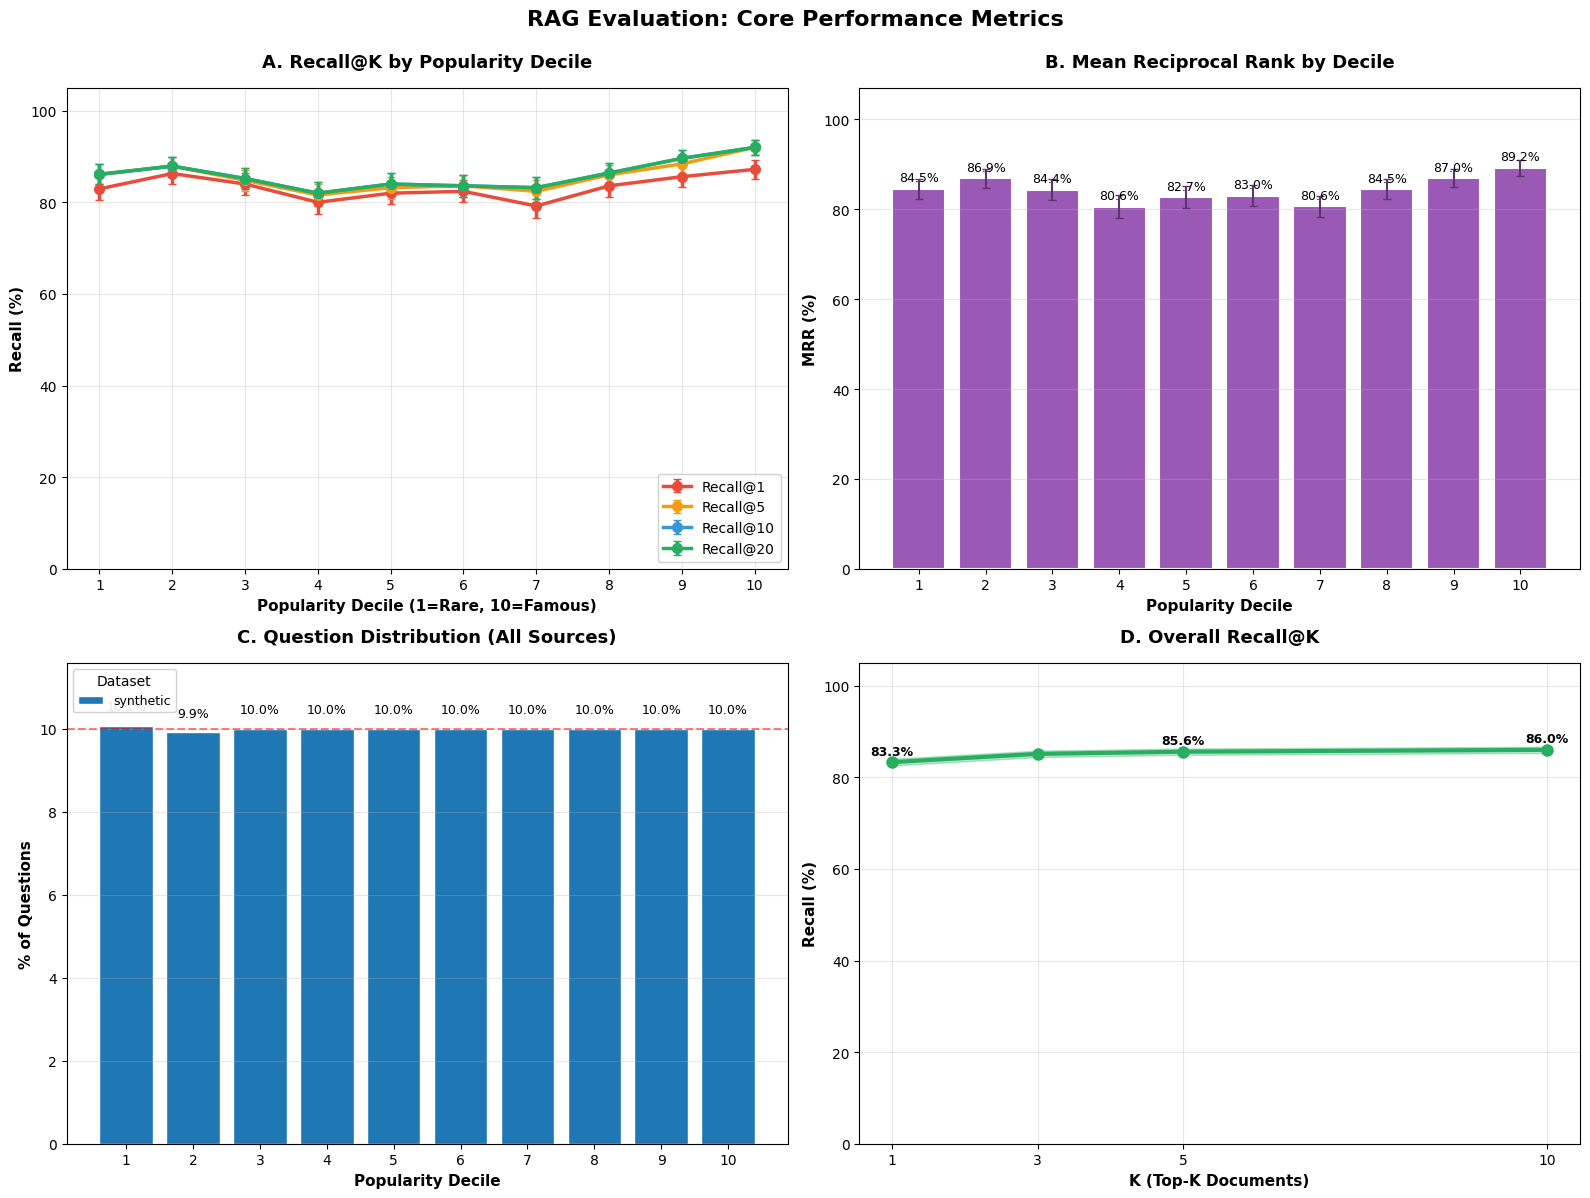

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Precompute per-decile stats
pop_deciles = list(range(10))

def _recall_by_decile(k):
    recalls = []
    errs = []
    for d in pop_deciles:
        df = results_df[results_df["pop_decile"] == d]
        n = len(df)
        if n == 0:
            recalls.append(0)
            errs.append(0)
            continue
        p = ((df["found_at_rank"].notna()) & (df["found_at_rank"] <= k)).mean()
        se = np.sqrt(p * (1 - p) / n)
        recalls.append(p)
        errs.append(se)
    return np.array(recalls), np.array(errs)

def _mrr_by_decile():
    mrrs = []
    errs = []
    for d in pop_deciles:
        df = results_df[results_df["pop_decile"] == d]
        n = len(df)
        if n == 0:
            mrrs.append(0)
            errs.append(0)
            continue
        rr = df["found_at_rank"].apply(lambda x: 1 / x if pd.notna(x) else 0)
        mrr = rr.mean()
        se = rr.std(ddof=1) / np.sqrt(n) if n > 1 else 0
        mrrs.append(mrr)
        errs.append(se)
    return np.array(mrrs), np.array(errs)

# Panel 1: Recall@K Curves by Decile (with SE bars)
ax = axes[0, 0]
k_plot = [1, 5, 10, 20]
colors_k = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']

for k_idx, k in enumerate(k_plot):
    recalls, errs = _recall_by_decile(k)
    ax.errorbar(
        np.array(pop_deciles) + 1,
        recalls * 100,
        yerr=errs * 100,
        marker='o',
        linewidth=2.5,
        color=colors_k[k_idx],
        label=f'Recall@{k}',
        markersize=7,
        capsize=3,
    )

ax.set_xlabel("Popularity Decile (1=Rare, 10=Famous)", fontsize=11, fontweight='bold')
ax.set_ylabel("Recall (%)", fontsize=11, fontweight='bold')
ax.set_title("A. Recall@K by Popularity Decile", fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 105)

# Panel 2: MRR by Decile (with SE bars)
ax = axes[0, 1]
mrr_vals, mrr_errs = _mrr_by_decile()

bars = ax.bar(np.array(pop_deciles) + 1, mrr_vals * 100, color='#9b59b6', edgecolor='white', linewidth=1.5)
ax.errorbar(
    np.array(pop_deciles) + 1,
    mrr_vals * 100,
    yerr=mrr_errs * 100,
    fmt='none',
    ecolor='#5e3370',
    elinewidth=1.5,
    capsize=3,
)

for bar, val in zip(bars, mrr_vals * 100):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("MRR (%)", fontsize=11, fontweight='bold')
ax.set_title("B. Mean Reciprocal Rank by Decile", fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, max(max(mrr_vals * 100) * 1.2, 5))

# Panel 3: Question Distribution (All sources)
ax = axes[1, 0]
q_counts = results_df['pop_decile'].value_counts().sort_index()
q_pcts = (q_counts / len(results_df)) * 100

if "dataset" in results_df.columns:
    datasets = list(results_df["dataset"].dropna().unique())
    datasets.sort()
    bottoms = np.zeros(10)
    colors = plt.cm.tab10.colors

    for i, ds in enumerate(datasets):
        ds_counts = (
            results_df[results_df["dataset"] == ds]["pop_decile"]
            .value_counts()
            .reindex(range(10), fill_value=0)
        )
        ds_pcts = (ds_counts / len(results_df)) * 100
        ax.bar(
            np.arange(1, 11),
            ds_pcts.values,
            bottom=bottoms,
            color=colors[i % len(colors)],
            edgecolor='white',
            linewidth=1.0,
            label=ds,
        )
        bottoms += ds_pcts.values

    for i, total in enumerate(bottoms):
        if total > 0.5:
            ax.text(i + 1, total + 0.3, f'{total:.1f}%',
                    ha='center', va='bottom', fontsize=9)

    ax.legend(fontsize=9, framealpha=0.9, title="Dataset")
else:
    real_counts = []
    synth_counts = []
    for decile in range(10):
        decile_df = results_df[results_df['pop_decile'] == decile]
        if 'is_synthetic' in results_df.columns and len(decile_df) > 0:
            synth = (decile_df['is_synthetic'].sum() / len(results_df)) * 100
            real = ((~decile_df['is_synthetic']).sum() / len(results_df)) * 100
        else:
            synth = 0
            real = q_pcts.get(decile, 0)
        synth_counts.append(synth)
        real_counts.append(real)

    x_pos = np.arange(1, 11)
    ax.bar(x_pos, real_counts, color='#3498db', edgecolor='white', linewidth=1.5, label='Real')
    ax.bar(x_pos, synth_counts, bottom=real_counts, color='#e67e22',
           edgecolor='white', linewidth=1.5, label='Synthetic')

    for i, (r, s) in enumerate(zip(real_counts, synth_counts)):
        total = r + s
        if total > 0.5:
            ax.text(i + 1, total + 0.3, f'{total:.1f}%',
                    ha='center', va='bottom', fontsize=9)

    ax.legend(fontsize=10, framealpha=0.9)

ax.axhline(10, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Uniform (10%)')
ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Questions", fontsize=11, fontweight='bold')
ax.set_title("C. Question Distribution (All Sources)", fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, max(q_pcts) * 1.15 if len(q_pcts) > 0 else 15)

# Panel 4: Overall Recall@K Curve (with SE band)
ax = axes[1, 1]
k_vals = [k for k in K_VALUES if k <= 30]
recall_vals = np.array([metrics[f'recall@{k}'] for k in k_vals])

n_total = len(results_df)
recall_errs = np.array([np.sqrt(p * (1 - p) / n_total) for p in recall_vals])

ax.plot(k_vals, recall_vals * 100, marker='o', linewidth=3, color='#27ae60', markersize=8)
ax.fill_between(k_vals, (recall_vals - recall_errs) * 100, (recall_vals + recall_errs) * 100, alpha=0.3, color='#27ae60')

for k in [1, 5, 10, 20, 30]:
    if k in k_vals:
        idx = k_vals.index(k)
        if recall_vals[idx] * 100 > 0.5:
            ax.text(k, recall_vals[idx] * 100 + 1, f'{recall_vals[idx] * 100:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel("K (Top-K Documents)", fontsize=11, fontweight='bold')
ax.set_ylabel("Recall (%)", fontsize=11, fontweight='bold')
ax.set_title("D. Overall Recall@K", fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_vals)
ax.set_ylim(0, 105)

plt.suptitle("RAG Evaluation: Core Performance Metrics",
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Figure 1B: Recall@K by Dataset

Bar chart of Recall@$K$ (with standard error) for each dataset.

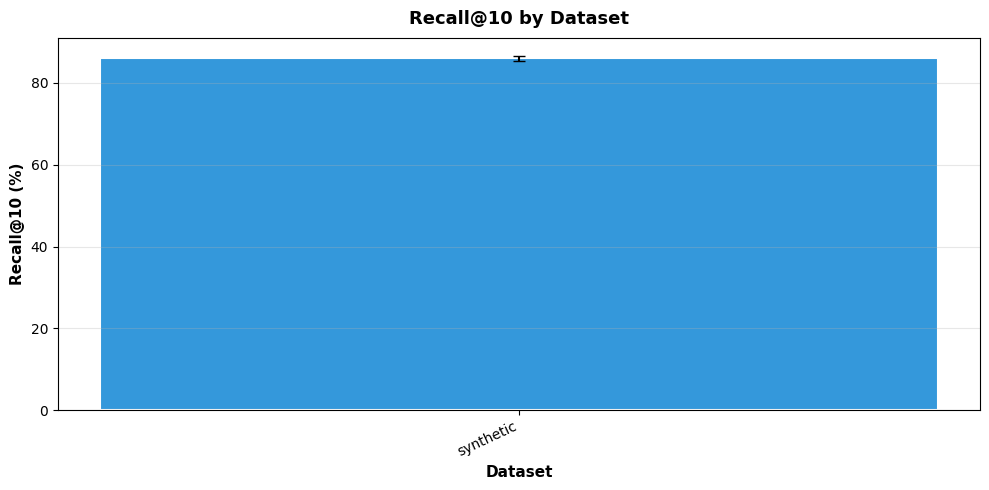

In [49]:
# Recall@K by dataset (with standard error)
if "dataset" in results_df.columns:
    dataset_stats = []
    for dataset, df in results_df.groupby("dataset"):
        n = len(df)
        if n == 0:
            continue
        p = ((df["found_at_rank"].notna()) & (df["found_at_rank"] <= TOP_K)).mean()
        se = np.sqrt(p * (1 - p) / n)
        dataset_stats.append({"dataset": dataset, "recall": p, "se": se, "n": n})

    ds_df = pd.DataFrame(dataset_stats).sort_values("recall", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(ds_df["dataset"], ds_df["recall"] * 100, yerr=ds_df["se"] * 100,
           color="#3498db", edgecolor="white", linewidth=1.5, capsize=4)
    ax.set_ylabel(f"Recall@{TOP_K} (%)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Dataset", fontsize=11, fontweight="bold")
    ax.set_title(f"Recall@{TOP_K} by Dataset", fontsize=13, fontweight="bold", pad=10)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No 'dataset' column found in results_df.")

### Figure 2: Popularity Bias Analysis

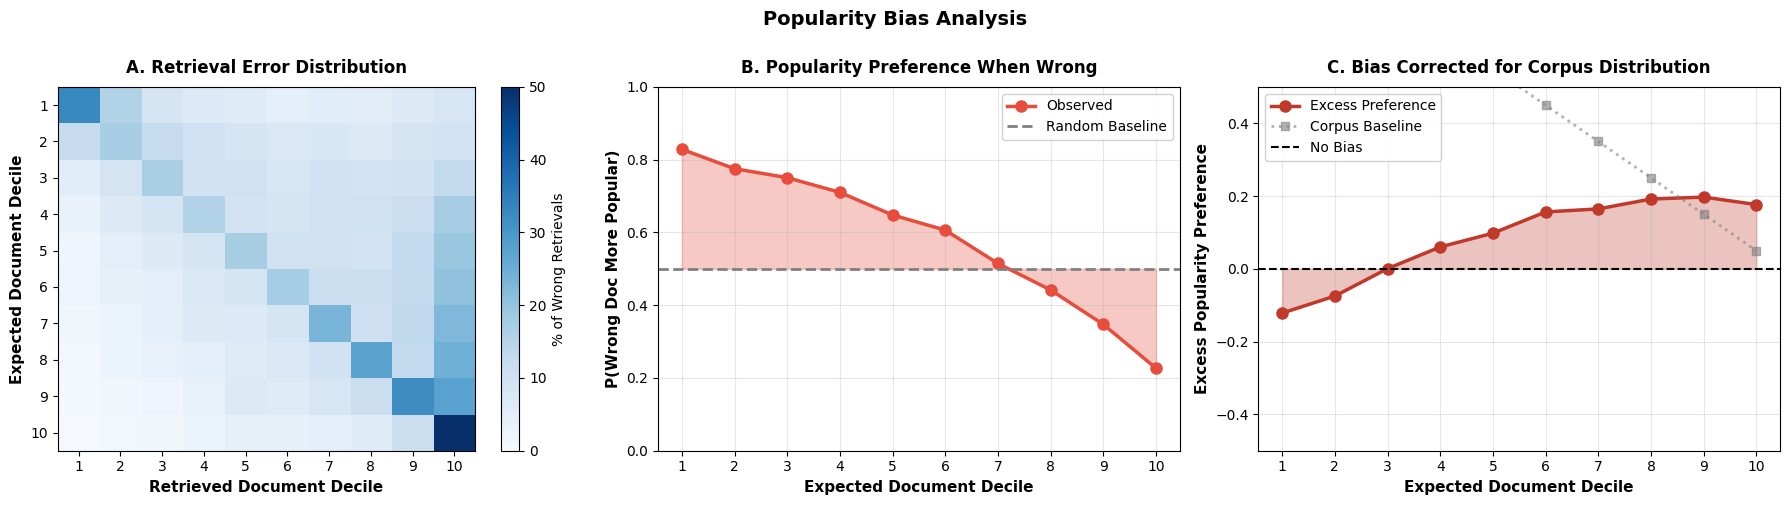

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Bias Heatmap
ax = axes[0]
heatmap_data = np.zeros((10, 10))

for _, row in results_df.iterrows():
    expected_dec = int(row['pop_decile'])
    wrong_pops = row['wrong_docs_popularities']
    if wrong_pops:
        for wp in wrong_pops:
            wrong_dec = pd.cut([wp], bins=corpus_bin_edges, labels=False, include_lowest=True)[0]
            if not pd.isna(wrong_dec):
                heatmap_data[expected_dec, int(wrong_dec)] += 1

row_sums = heatmap_data.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
heatmap_pct = heatmap_data / row_sums * 100

im = ax.imshow(heatmap_pct, cmap='Blues', aspect='auto', vmin=0, vmax=50)
plt.colorbar(im, ax=ax, label='% of Wrong Retrievals')
ax.set_xlabel("Retrieved Document Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("Expected Document Decile", fontsize=11, fontweight='bold')
ax.set_title("A. Retrieval Error Distribution", fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(1, 11))
ax.set_yticklabels(range(1, 11))

# Panel 2: Popularity Preference
ax = axes[1]
bias_frac_by_decile = []

for d in range(10):
    subset = results_df[results_df["pop_decile"] == d]
    num_higher = 0
    num_total = 0
    
    for wp_list, pop in zip(subset["wrong_docs_popularities"], subset["popularity"]):
        if not wp_list:
            continue
        for wp in wp_list:
            num_total += 1
            if wp > pop:
                num_higher += 1
    
    bias_frac_by_decile.append(num_higher / num_total if num_total > 0 else np.nan)

ax.plot(range(1, 11), bias_frac_by_decile, marker="o", linewidth=2.5, 
        color='#e74c3c', markersize=8, label="Observed")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=2, label="Random Baseline")
ax.fill_between(range(1, 11), bias_frac_by_decile, 0.5, alpha=0.3, color='#e74c3c')

ax.set_xlabel("Expected Document Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("P(Wrong Doc More Popular)", fontsize=11, fontweight='bold')
ax.set_title("B. Popularity Preference When Wrong", fontsize=12, fontweight='bold', pad=10)
ax.set_ylim(0, 1)
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.3)
ax.legend(fontsize=10, framealpha=0.9)

# Panel 3: Excess Preference
ax = axes[2]
baseline_by_decile = [(9 - d + 0.5) / 10 for d in range(10)]
excess_preference = [obs - exp if not np.isnan(obs) else np.nan 
                    for obs, exp in zip(bias_frac_by_decile, baseline_by_decile)]

ax.plot(range(1, 11), excess_preference, marker="o", color="#c0392b", 
        linewidth=2.5, markersize=8, label="Excess Preference")
ax.plot(range(1, 11), baseline_by_decile, marker="s", linestyle=":", 
        color="gray", alpha=0.6, linewidth=2, label="Corpus Baseline")
ax.axhline(0, color="black", linestyle="--", linewidth=1.5, label="No Bias")
ax.fill_between(range(1, 11), excess_preference, 0, alpha=0.3, color='#c0392b')

ax.set_xlabel("Expected Document Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("Excess Popularity Preference", fontsize=11, fontweight='bold')
ax.set_title("C. Bias Corrected for Corpus Distribution", fontsize=12, fontweight='bold', pad=10)
ax.set_ylim(-0.5, 0.5)
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.3)
ax.legend(fontsize=10, framealpha=0.9)

plt.suptitle("Popularity Bias Analysis", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Figure 3: Detailed Decile Analysis

/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_25519/4271215982.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correct_pcts = results_df.groupby('pop_decile').apply(


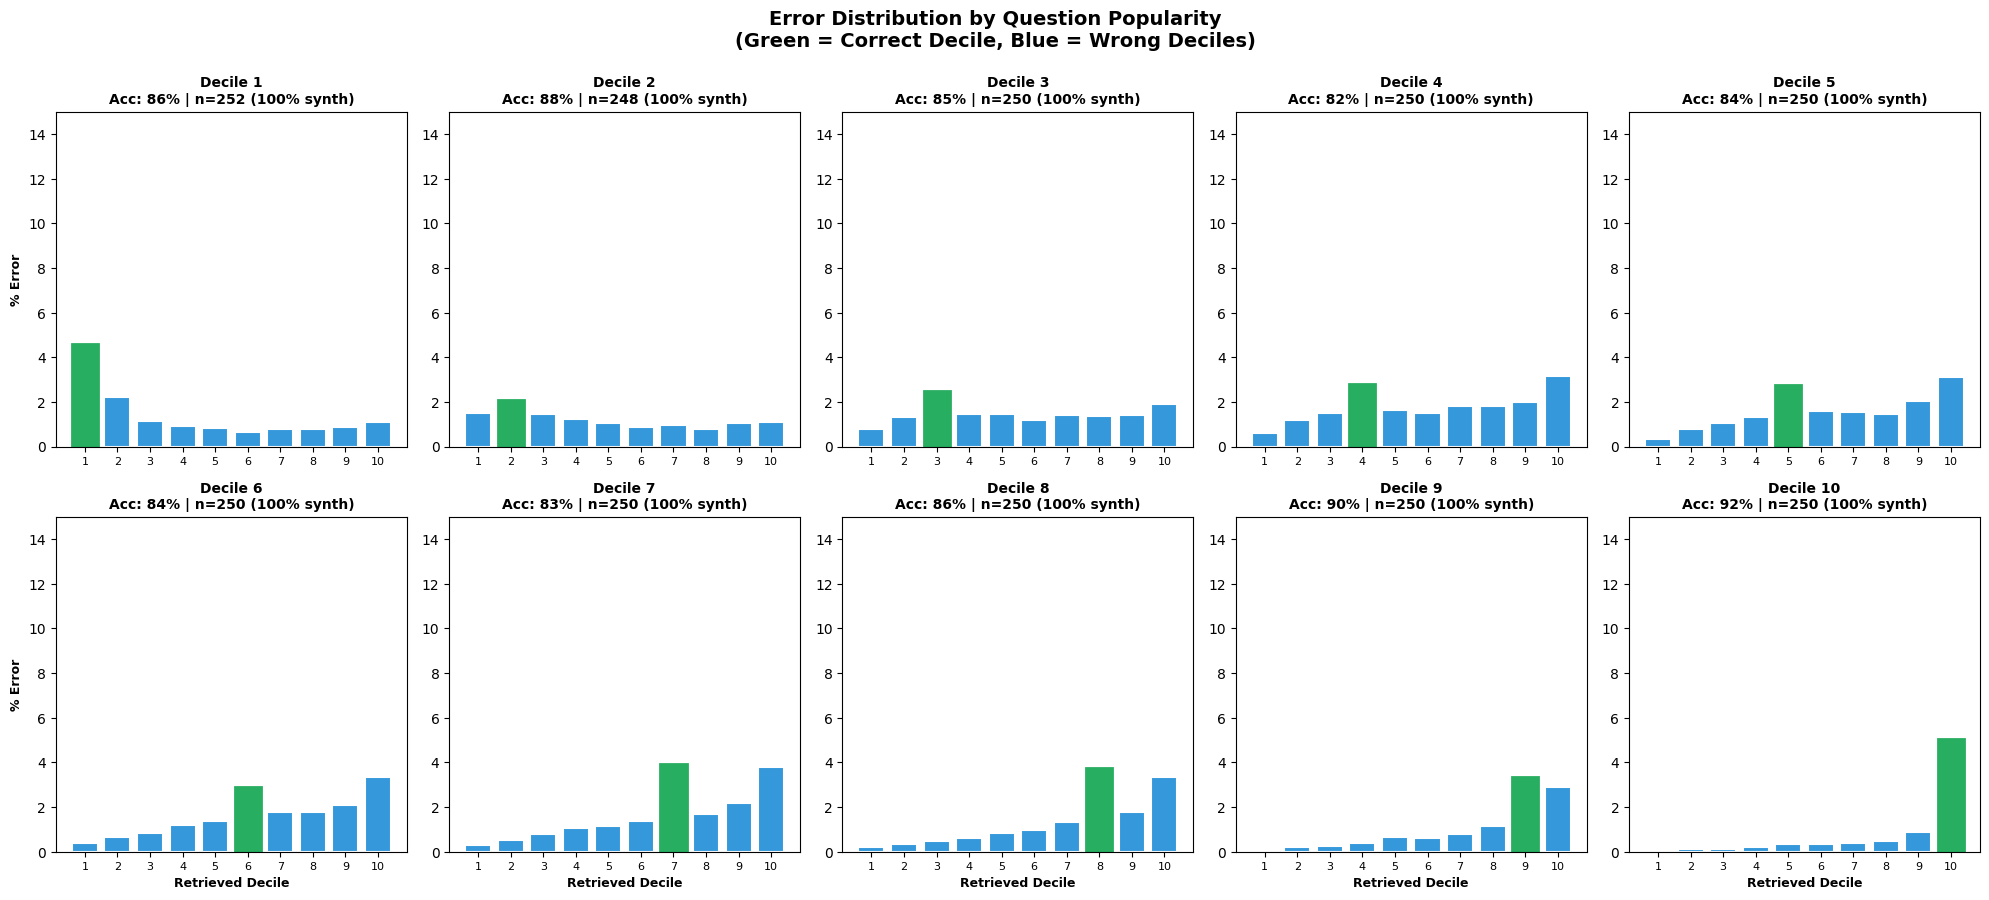

In [51]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

correct_pcts = results_df.groupby('pop_decile').apply(
    lambda df: ((df['found_at_rank'].notna()) & (df['found_at_rank'] <= TOP_K)).mean() * 100
).reindex(range(10), fill_value=0)

for decile in range(10):
    ax = axes[decile]
    subset = results_df[results_df['pop_decile'] == decile]
    
    if len(subset) < 3:
        ax.text(0.5, 0.5, f"Insufficient Data\n(n={len(subset)})", 
                ha='center', va='center', fontsize=11, fontweight='bold')
        ax.set_title(f"Decile {decile+1}", fontsize=11, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    wrong_counts = np.zeros(10)
    total_wrong = 0
    for _, row in subset.iterrows():
        for wp in (row['wrong_docs_popularities'] or []):
            w_dec = pd.cut([wp], bins=corpus_bin_edges, labels=False, include_lowest=True)[0]
            if not pd.isna(w_dec):
                wrong_counts[int(w_dec)] += 1
                total_wrong += 1
    
    if total_wrong > 0:
        raw = (wrong_counts / total_wrong) * 100
        scaled = raw * ((100 - correct_pcts[decile]) / 100)
    else:
        scaled = np.zeros(10)
    
    bars = ax.bar(range(10), scaled, color='#3498db', edgecolor='white', linewidth=1.5, width=0.8)
    bars[decile].set_color('#27ae60')
    bars[decile].set_linewidth(2)
    
    n_synth = int(subset.get('is_synthetic', pd.Series([False]*len(subset))).sum())
    synth_pct = n_synth / len(subset) * 100 if len(subset) > 0 else 0
    
    ax.set_title(f"Decile {decile+1}\nAcc: {correct_pcts[decile]:.0f}% | n={len(subset)} ({synth_pct:.0f}% synth)", 
                fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(15, scaled.max() * 1.3) if scaled.max() > 0 else 15)
    ax.set_xticks(range(10))
    ax.set_xticklabels(range(1, 11), fontsize=8)
    
    if decile % 5 == 0:
        ax.set_ylabel("% Error", fontsize=9, fontweight='bold')
    if decile >= 5:
        ax.set_xlabel("Retrieved Decile", fontsize=9, fontweight='bold')

plt.suptitle("Error Distribution by Question Popularity\n(Green = Correct Decile, Blue = Wrong Deciles)", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 7️⃣ BM25 vs Dense Vector Comparison

This section builds a BM25 index, runs keyword retrieval, and compares it to dense vector retrieval using the same questions and popularity metadata.

### 7.1 Load/Create BM25 Index

Build or load a BM25 index from the same corpus used for dense retrieval.

In [52]:
# Load/Create BM25 Index
from rag.bm25_rag_service import BM25RagService

print("Setting up BM25 retrieval...")
BM25_INDEX_DIR = INDEX_DIR.parent / "bm25_index"
BM25_COLLECTION_NAME = COLLECTION_NAME

bm25_service = BM25RagService(k=MAX_K)

# Try to load existing BM25 index
bm25_index = bm25_service.load_index(output_dir=BM25_INDEX_DIR, collection_name=BM25_COLLECTION_NAME)

if bm25_index is None:
    print("BM25 index not found. Creating from in-memory corpus...")
    print("⚠️ This may take several minutes for large corpora...")

    corpus_df = service.get_corpus_dataframe(index, batch_size=10_000)

    bm25_index, num_docs = bm25_service.index_from_dataframe(
        df=corpus_df,
        text_field="text",
        metadata_fields=["wikipedia_id", "wikipedia_title", "popularity_avg"],
        output_dir=BM25_INDEX_DIR,
        collection_name=BM25_COLLECTION_NAME,
    )
    print(f"✓ Created BM25 index with {num_docs:,} documents")
else:
    print(f"✓ Loaded existing BM25 index from {BM25_INDEX_DIR}")

print("✓ BM25 service ready")

Setting up BM25 retrieval...


Loaded BM25 index from /Users/cyro/Documents/VSC/PopularityBias/data/wiki_200k_balanced_qa_s_250_only/bm25_index/native_rag.pkl


✓ Loaded existing BM25 index from /Users/cyro/Documents/VSC/PopularityBias/data/wiki_200k_balanced_qa_s_250_only/bm25_index
✓ BM25 service ready


### 7.2 Run BM25 Retrieval

Retrieve top-$K$ with BM25 using the **full corpus index** (created in 7.1) for fair comparison.

**Note:** Previously this used dense-prefiltered candidates, which gave BM25 an unfair advantage since it could only see documents that Dense already ranked highly.

In [ ]:
# Run BM25 Retrieval (FAIR comparison using full BM25 index)
# Note: Cell 28 already created/loaded bm25_index from the full corpus

print(f"\nRunning BM25 retrieval (full corpus) on {len(qa_df):,} questions...")

bm25_results = []
for idx, row in tqdm(qa_df.iterrows(), total=len(qa_df), desc="BM25 retrieval"):
    question = row["question_text"]
    expected_id = str(row["wikipedia_id"]).strip()
    
    # Use the FULL BM25 index (created in cell 28) for fair comparison
    bm25_docs = bm25_service.retrieve_documents(bm25_index, question, top_k=MAX_K)
    
    # Extract IDs and metadata
    topk_ids = [doc.metadata.get("wikipedia_id", "") for doc in bm25_docs]
    topk_pops = [doc.metadata.get("popularity_avg", None) for doc in bm25_docs]
    
    # Normalize IDs for matching
    topk_ids = [str(doc_id).strip() for doc_id in topk_ids]
    
    bm25_results.append({
        "question": question,
        "wikipedia_id": expected_id,
        "topk_ids": topk_ids,
        "topk_popularities": topk_pops,
    })

bm25_results_df = pd.DataFrame(bm25_results)

# Merge metadata
bm25_results_df = bm25_results_df.merge(
    meta_df[[c for c in meta_df.columns if c in ["popularity", "is_synthetic", "dataset", "wikipedia_title", "question", "wikipedia_id"]]],
    on=["question", "wikipedia_id"],
    how="left"
)

# Compute evaluation metrics
bm25_results_df = pd.concat([bm25_results_df, bm25_results_df.apply(_compute_eval, axis=1)], axis=1)

# Add deciles
bm25_results_df['pop_decile'] = pd.cut(
    bm25_results_df['popularity'].fillna(0),
    bins=corpus_bin_edges,
    labels=False,
    include_lowest=True
).fillna(0).astype(int)

# Add method label
bm25_results_df['method'] = 'BM25'
results_df['method'] = 'Dense Vector'

print(f"✓ BM25 retrieval complete: {len(bm25_results_df):,} results")


Running BM25 retrieval (dense-prefiltered) on 2,500 questions...


BM25 retrieval (prefiltered):  41%|████      | 1021/2500 [34:36<25:56,  1.05s/it]  

### 7.3 Compute Comparison Metrics

Compute Recall@K, MRR, and per-decile metrics for both retrieval methods.

In [ ]:
# Compute Comparison Metrics
print("\n" + "="*70)
print("📊 BM25 vs DENSE VECTOR COMPARISON")
print("="*70)

# Combine results for comparison
combined_df = pd.concat([results_df, bm25_results_df], ignore_index=True)

# Overall metrics comparison
comparison_metrics = {}

for method in ['Dense Vector', 'BM25']:
    method_df = combined_df[combined_df['method'] == method]
    method_metrics = {}
    
    # Recall@K
    for k in K_VALUES:
        recall = ((method_df['found_at_rank'].notna()) & 
                 (method_df['found_at_rank'] <= k)).sum() / len(method_df)
        method_metrics[f'recall@{k}'] = recall
    
    # MRR
    rr = method_df['found_at_rank'].apply(lambda x: 1/x if pd.notna(x) else 0)
    method_metrics['mrr'] = rr.mean()
    
    # Per-decile Recall@10
    decile_recall = []
    for d in range(10):
        d_df = method_df[method_df['pop_decile'] == d]
        if len(d_df) > 0:
            r10 = ((d_df['found_at_rank'].notna()) & (d_df['found_at_rank'] <= 10)).mean()
            decile_recall.append(r10)
        else:
            decile_recall.append(np.nan)
    method_metrics['decile_recall@10'] = decile_recall
    
    comparison_metrics[method] = method_metrics

# Print comparison
print(f"\n{'Metric':<15} {'Dense Vector':>15} {'BM25':>15} {'Δ':>10}")
print("-" * 60)

for k in K_VALUES:
    dv = comparison_metrics['Dense Vector'][f'recall@{k}']
    bm = comparison_metrics['BM25'][f'recall@{k}']
    delta = dv - bm
    print(f"Recall@{k:<2}      {dv:>14.2%} {bm:>14.2%} {delta:>9.2%}")

dv_mrr = comparison_metrics['Dense Vector']['mrr']
bm_mrr = comparison_metrics['BM25']['mrr']
print(f"MRR             {dv_mrr:>14.4f} {bm_mrr:>14.4f} {dv_mrr-bm_mrr:>9.4f}")

print("\n" + "="*70)
print(f"📈 DECILE-WISE RECALL@10 COMPARISON")
print("="*70)
print(f"{'Decile':<10} {'Dense Vector':>15} {'BM25':>15} {'Δ':>10} {'Winner':<15}")
print("-" * 70)

for d in range(10):
    dv_r = comparison_metrics['Dense Vector']['decile_recall@10'][d]
    bm_r = comparison_metrics['BM25']['decile_recall@10'][d]
    if not np.isnan(dv_r) and not np.isnan(bm_r):
        delta = dv_r - bm_r
        winner = "Dense Vector" if delta > 0.01 else ("BM25" if delta < -0.01 else "Tie")
        print(f"Decile {d+1:<3} {dv_r:>14.2%} {bm_r:>14.2%} {delta:>9.2%} {winner:<15}")

print("\n✓ Comparison metrics computed")


📊 BM25 vs DENSE VECTOR COMPARISON

Metric             Dense Vector            BM25          Δ
------------------------------------------------------------
Recall@1               83.32%         77.00%     6.32%
Recall@3               85.12%         83.84%     1.28%
Recall@5               85.60%         86.24%    -0.64%
Recall@10              86.00%         88.72%    -2.72%
MRR                     0.8434         0.8091    0.0343

📈 DECILE-WISE RECALL@10 COMPARISON
Decile        Dense Vector            BM25          Δ Winner         
----------------------------------------------------------------------
Decile 1           86.11%         87.30%    -1.19% BM25           
Decile 2           87.90%         87.90%     0.00% Tie            
Decile 3           85.20%         89.20%    -4.00% BM25           
Decile 4           82.00%         89.60%    -7.60% BM25           
Decile 5           84.00%         87.20%    -3.20% BM25           
Decile 6           83.60%         85.60%    -2.00% BM25 

/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_25519/3901957036.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([results_df, bm25_results_df], ignore_index=True)


### 7.4 Figure 4: Performance Comparison

Dense Vector vs BM25 on recall and MRR, both overall and by decile.

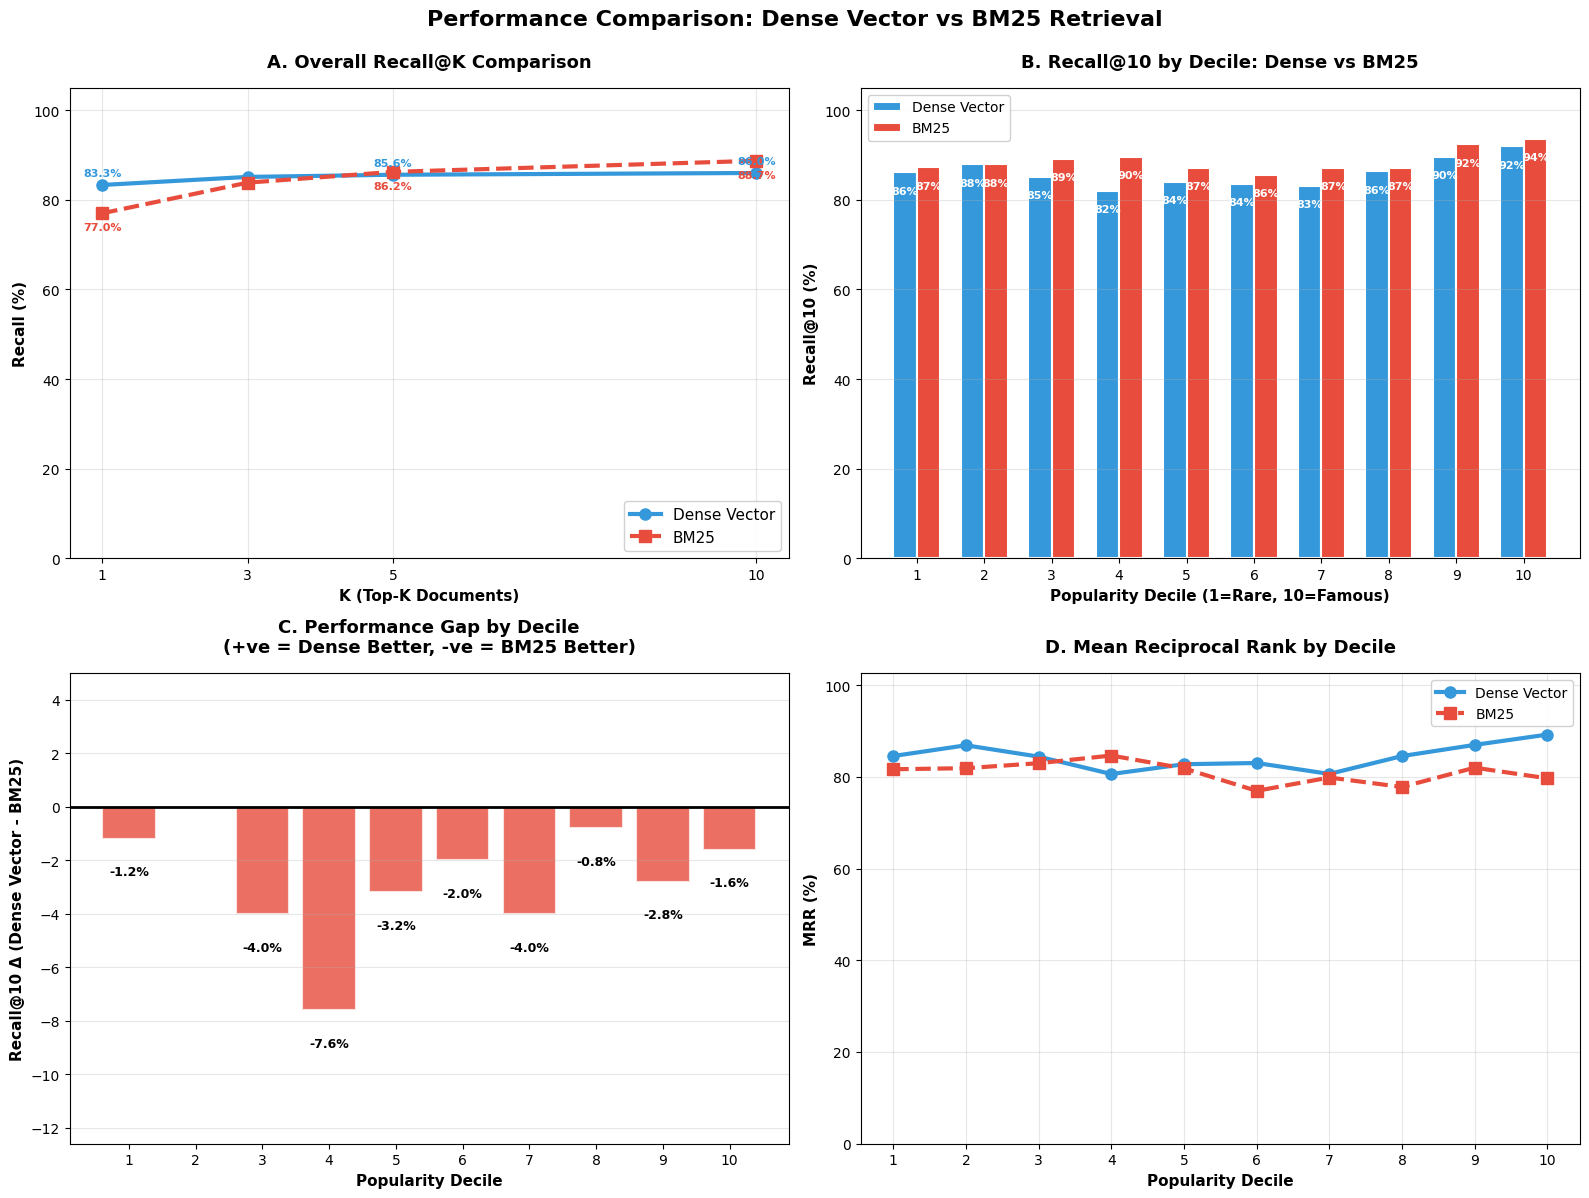

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Overall Recall@K Comparison
ax = axes[0, 0]
k_vals = [k for k in K_VALUES if k <= 30]

dv_recalls = [comparison_metrics['Dense Vector'][f'recall@{k}'] * 100 for k in k_vals]
bm_recalls = [comparison_metrics['BM25'][f'recall@{k}'] * 100 for k in k_vals]

ax.plot(k_vals, dv_recalls, marker='o', linewidth=3, color='#3498db', 
        markersize=8, label='Dense Vector', linestyle='-')
ax.plot(k_vals, bm_recalls, marker='s', linewidth=3, color='#e74c3c', 
        markersize=8, label='BM25', linestyle='--')

for k in [1, 5, 10, 20]:
    if k in k_vals:
        idx = k_vals.index(k)
        # Dense Vector
        ax.text(k, dv_recalls[idx] + 1.5, f'{dv_recalls[idx]:.1f}%',
                ha='center', va='bottom', fontsize=8, color='#3498db', fontweight='bold')
        # BM25
        ax.text(k, bm_recalls[idx] - 2, f'{bm_recalls[idx]:.1f}%',
                ha='center', va='top', fontsize=8, color='#e74c3c', fontweight='bold')

ax.set_xlabel("K (Top-K Documents)", fontsize=11, fontweight='bold')
ax.set_ylabel("Recall (%)", fontsize=11, fontweight='bold')
ax.set_title("A. Overall Recall@K Comparison", fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, framealpha=0.9, loc='lower right')
ax.set_xticks(k_vals)
ax.set_ylim(0, 105)

# Panel 2: Recall@10 by Decile Comparison
ax = axes[0, 1]
x_pos = np.arange(1, 11)
width = 0.35

dv_decile = comparison_metrics['Dense Vector']['decile_recall@10']
bm_decile = comparison_metrics['BM25']['decile_recall@10']

bars1 = ax.bar(x_pos - width/2, [r*100 for r in dv_decile], width, 
               label='Dense Vector', color='#3498db', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x_pos + width/2, [r*100 for r in bm_decile], width,
               label='BM25', color='#e74c3c', edgecolor='white', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 2:
            ax.text(bar.get_x() + bar.get_width()/2, height - 3,
                    f'{height:.0f}%', ha='center', va='top', fontsize=8, 
                    color='white', fontweight='bold')

ax.set_xlabel("Popularity Decile (1=Rare, 10=Famous)", fontsize=11, fontweight='bold')
ax.set_ylabel("Recall@10 (%)", fontsize=11, fontweight='bold')
ax.set_title("B. Recall@10 by Decile: Dense vs BM25", fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10, framealpha=0.9)
ax.set_ylim(0, 105)

# Panel 3: Performance Delta by Decile
ax = axes[1, 0]
deltas = [(dv - bm) * 100 for dv, bm in zip(dv_decile, bm_decile)]
colors = ['#27ae60' if d > 0 else '#e74c3c' for d in deltas]

bars = ax.bar(x_pos, deltas, color=colors, edgecolor='white', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='black', linestyle='-', linewidth=2)

for bar, delta in zip(bars, deltas):
    if abs(delta) > 0.5:
        y_pos = delta + (1 if delta > 0 else -1)
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{delta:+.1f}%', ha='center', 
                va='bottom' if delta > 0 else 'top',
                fontsize=9, fontweight='bold')

ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("Recall@10 Δ (Dense Vector - BM25)", fontsize=11, fontweight='bold')
ax.set_title("C. Performance Gap by Decile\n(+ve = Dense Better, -ve = BM25 Better)", 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(min(deltas) - 5, max(deltas) + 5)

# Panel 4: MRR Comparison by Decile
ax = axes[1, 1]

dv_mrr_decile = []
bm_mrr_decile = []

for d in range(10):
    # Dense Vector MRR
    dv_df = results_df[results_df['pop_decile'] == d]
    if len(dv_df) > 0:
        dv_rr = dv_df['found_at_rank'].apply(lambda x: 1/x if pd.notna(x) else 0)
        dv_mrr_decile.append(dv_rr.mean() * 100)
    else:
        dv_mrr_decile.append(0)
    
    # BM25 MRR
    bm_df = bm25_results_df[bm25_results_df['pop_decile'] == d]
    if len(bm_df) > 0:
        bm_rr = bm_df['found_at_rank'].apply(lambda x: 1/x if pd.notna(x) else 0)
        bm_mrr_decile.append(bm_rr.mean() * 100)
    else:
        bm_mrr_decile.append(0)

ax.plot(x_pos, dv_mrr_decile, marker='o', linewidth=3, color='#3498db',
        markersize=8, label='Dense Vector', linestyle='-')
ax.plot(x_pos, bm_mrr_decile, marker='s', linewidth=3, color='#e74c3c',
        markersize=8, label='BM25', linestyle='--')

ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("MRR (%)", fontsize=11, fontweight='bold')
ax.set_title("D. Mean Reciprocal Rank by Decile", fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xticks(x_pos)
ax.set_ylim(0, max(max(dv_mrr_decile), max(bm_mrr_decile)) * 1.15)

plt.suptitle("Performance Comparison: Dense Vector vs BM25 Retrieval",
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 7.5 Figure 5: Popularity Bias Comparison

Compares popularity bias signals between Dense Vector and BM25 retrieval.

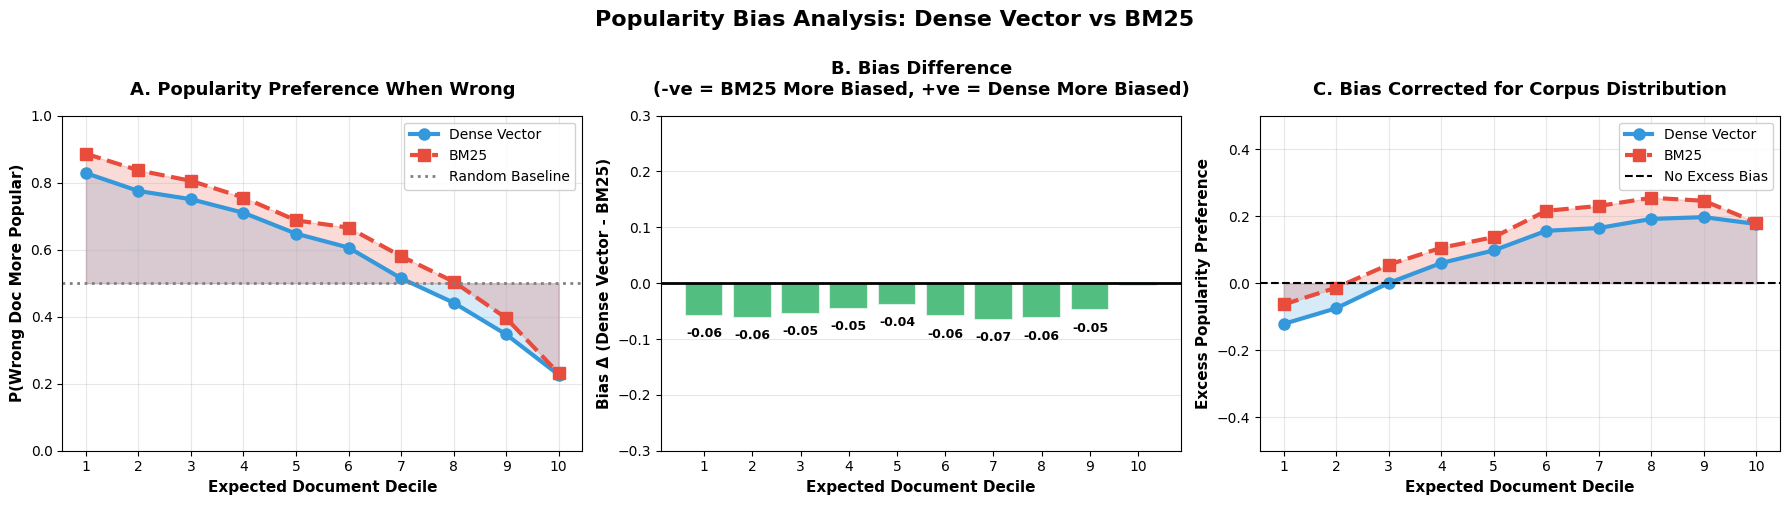

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Compute popularity bias for both methods
def compute_bias(df):
    bias_by_decile = []
    for d in range(10):
        subset = df[df["pop_decile"] == d]
        num_higher = 0
        num_total = 0
        
        for wp_list, pop in zip(subset["wrong_docs_popularities"], subset["popularity"]):
            if not wp_list:
                continue
            for wp in wp_list:
                num_total += 1
                if wp > pop:
                    num_higher += 1
        
        bias_by_decile.append(num_higher / num_total if num_total > 0 else np.nan)
    return bias_by_decile

dv_bias = compute_bias(results_df)
bm_bias = compute_bias(bm25_results_df)

# Panel 1: Side-by-side Popularity Preference
ax = axes[0]
x_pos = np.arange(1, 11)

ax.plot(x_pos, dv_bias, marker='o', linewidth=3, color='#3498db',
        markersize=8, label='Dense Vector', linestyle='-')
ax.plot(x_pos, bm_bias, marker='s', linewidth=3, color='#e74c3c',
        markersize=8, label='BM25', linestyle='--')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=2, label='Random Baseline')

ax.fill_between(x_pos, dv_bias, 0.5, alpha=0.2, color='#3498db')
ax.fill_between(x_pos, bm_bias, 0.5, alpha=0.2, color='#e74c3c')

ax.set_xlabel("Expected Document Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("P(Wrong Doc More Popular)", fontsize=11, fontweight='bold')
ax.set_title("A. Popularity Preference When Wrong", fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, 1)
ax.set_xticks(x_pos)
ax.grid(alpha=0.3)
ax.legend(fontsize=10, framealpha=0.9)

# Panel 2: Bias Delta (Dense - BM25)
ax = axes[1]
bias_deltas = [dv - bm if not (np.isnan(dv) or np.isnan(bm)) else 0 
               for dv, bm in zip(dv_bias, bm_bias)]
colors = ['#27ae60' if d < 0 else '#e74c3c' for d in bias_deltas]

bars = ax.bar(x_pos, bias_deltas, color=colors, edgecolor='white', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='black', linestyle='-', linewidth=2)

for bar, delta in zip(bars, bias_deltas):
    if abs(delta) > 0.02:
        y_pos = delta + (0.02 if delta > 0 else -0.02)
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{delta:+.2f}', ha='center', 
                va='bottom' if delta > 0 else 'top',
                fontsize=9, fontweight='bold')

ax.set_xlabel("Expected Document Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("Bias Δ (Dense Vector - BM25)", fontsize=11, fontweight='bold')
ax.set_title("B. Bias Difference\n(-ve = BM25 More Biased, +ve = Dense More Biased)", 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.3, 0.3)

# Panel 3: Excess Bias Comparison (corrected for corpus distribution)
ax = axes[2]
baseline_by_decile = [(9 - d + 0.5) / 10 for d in range(10)]

dv_excess = [obs - exp if not np.isnan(obs) else np.nan 
             for obs, exp in zip(dv_bias, baseline_by_decile)]
bm_excess = [obs - exp if not np.isnan(obs) else np.nan 
             for obs, exp in zip(bm_bias, baseline_by_decile)]

ax.plot(x_pos, dv_excess, marker='o', linewidth=3, color='#3498db',
        markersize=8, label='Dense Vector', linestyle='-')
ax.plot(x_pos, bm_excess, marker='s', linewidth=3, color='#e74c3c',
        markersize=8, label='BM25', linestyle='--')
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='No Excess Bias')

ax.fill_between(x_pos, dv_excess, 0, alpha=0.2, color='#3498db')
ax.fill_between(x_pos, bm_excess, 0, alpha=0.2, color='#e74c3c')

ax.set_xlabel("Expected Document Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("Excess Popularity Preference", fontsize=11, fontweight='bold')
ax.set_title("C. Bias Corrected for Corpus Distribution", fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(-0.5, 0.5)
ax.set_xticks(x_pos)
ax.grid(alpha=0.3)
ax.legend(fontsize=10, framealpha=0.9)

plt.suptitle("Popularity Bias Analysis: Dense Vector vs BM25",
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 7.6 Figure 6: Detailed Decile Comparison

Side-by-side error distributions across deciles for Dense Vector (top) and BM25 (bottom).

/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_25519/293353233.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dv_correct = results_df.groupby('pop_decile').apply(
/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_25519/293353233.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bm_correct = bm25_results_df.groupby('pop_decile').apply(


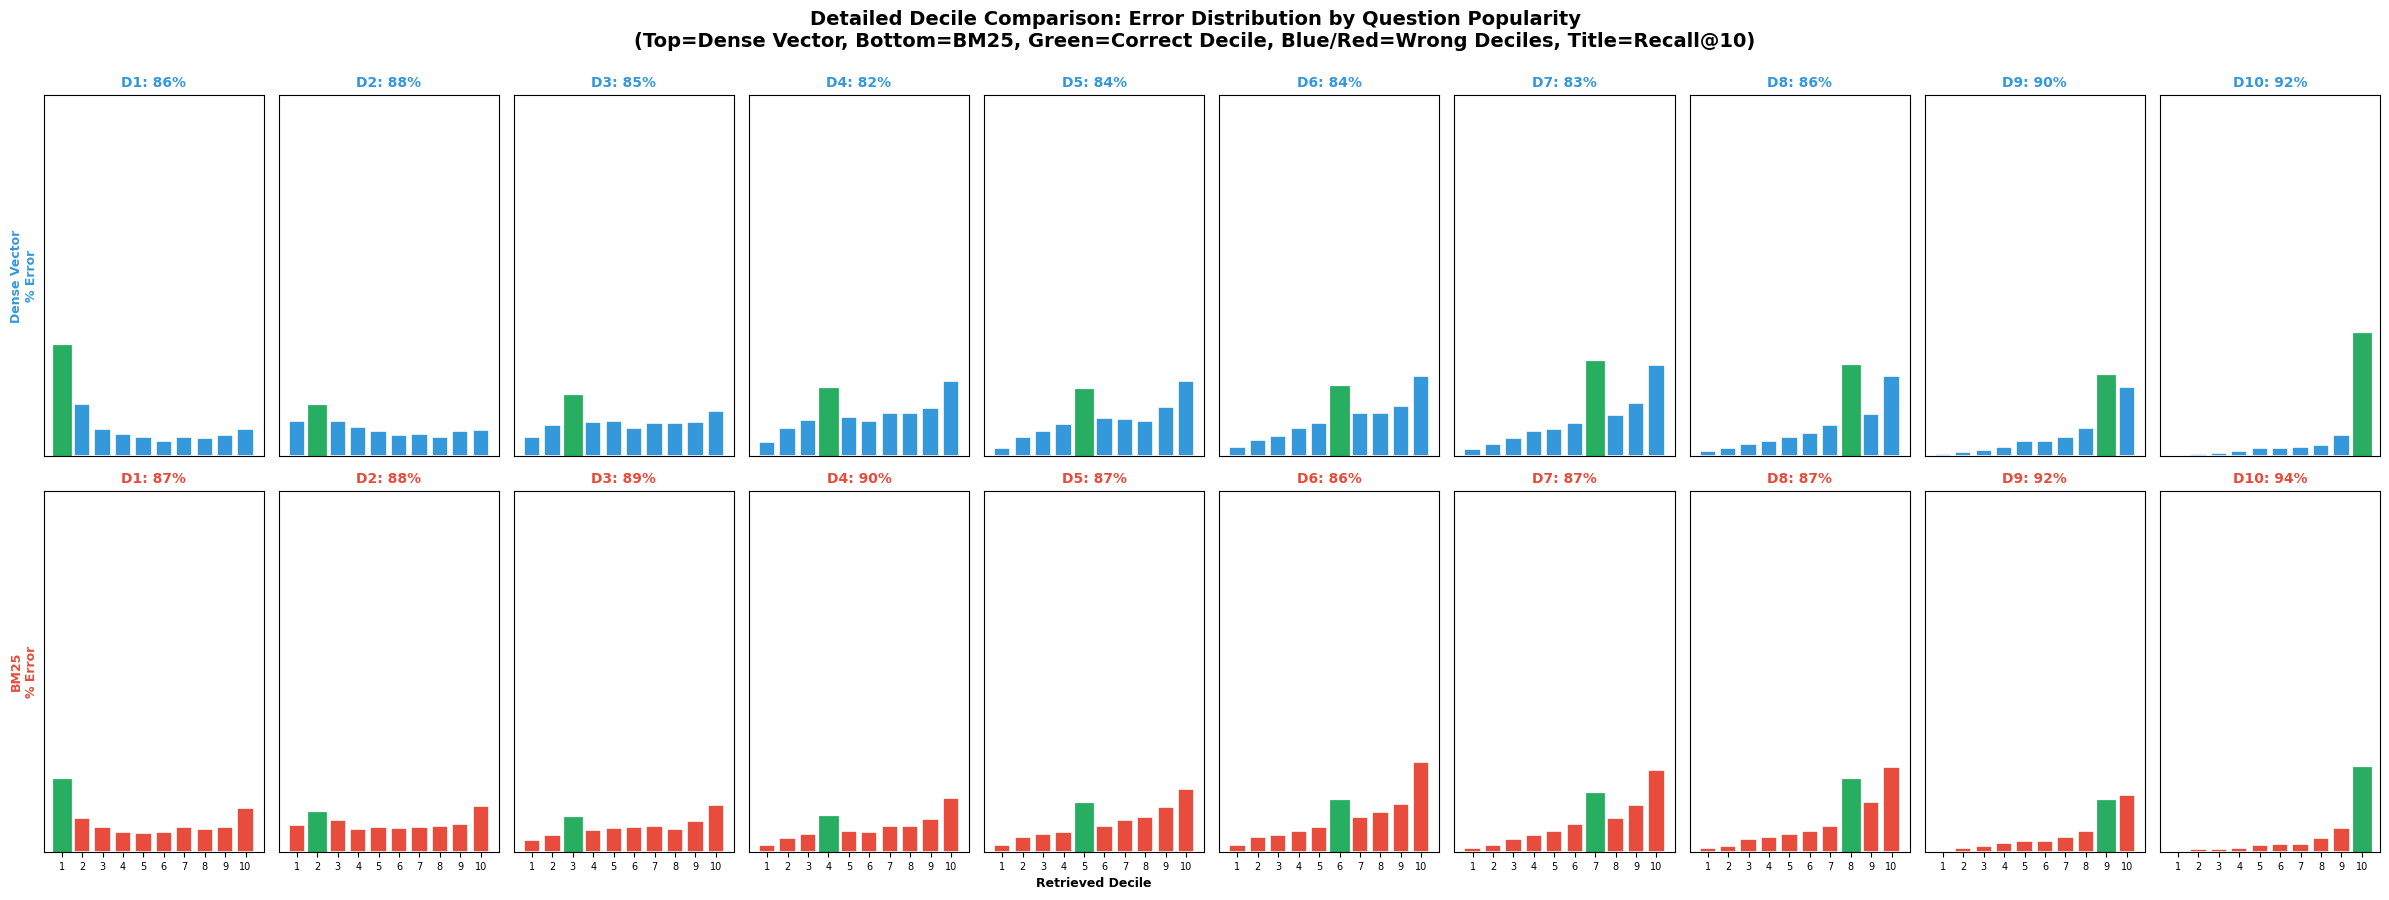

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(24, 9))

# Compute correct percentages for both methods
dv_correct = results_df.groupby('pop_decile').apply(
    lambda df: ((df['found_at_rank'].notna()) & (df['found_at_rank'] <= TOP_K)).mean() * 100
).reindex(range(10), fill_value=0)

bm_correct = bm25_results_df.groupby('pop_decile').apply(
    lambda df: ((df['found_at_rank'].notna()) & (df['found_at_rank'] <= TOP_K)).mean() * 100
).reindex(range(10), fill_value=0)

for decile in range(10):
    # Dense Vector (top row)
    ax_dv = axes[0, decile]
    dv_subset = results_df[results_df['pop_decile'] == decile]
    
    if len(dv_subset) >= 3:
        wrong_counts = np.zeros(10)
        total_wrong = 0
        for _, row in dv_subset.iterrows():
            for wp in (row['wrong_docs_popularities'] or []):
                w_dec = pd.cut([wp], bins=corpus_bin_edges, labels=False, include_lowest=True)[0]
                if not pd.isna(w_dec):
                    wrong_counts[int(w_dec)] += 1
                    total_wrong += 1
        
        if total_wrong > 0:
            raw = (wrong_counts / total_wrong) * 100
            scaled = raw * ((100 - dv_correct[decile]) / 100)
        else:
            scaled = np.zeros(10)
        
        bars = ax_dv.bar(range(10), scaled, color='#3498db', edgecolor='white', linewidth=1.2, width=0.8)
        bars[decile].set_color('#27ae60')
        bars[decile].set_linewidth(2)
        
        ax_dv.set_title(f"D{decile+1}: {dv_correct[decile]:.0f}%", 
                        fontsize=10, fontweight='bold', color='#3498db')
    else:
        ax_dv.text(0.5, 0.5, f"n={len(dv_subset)}", 
                   ha='center', va='center', fontsize=9, transform=ax_dv.transAxes)
        ax_dv.set_title(f"D{decile+1}", fontsize=10, fontweight='bold', color='#3498db')
    
    ax_dv.set_ylim(0, 15)
    ax_dv.set_xticks([])
    ax_dv.set_yticks([])
    if decile == 0:
        ax_dv.set_ylabel("Dense Vector\n% Error", fontsize=9, fontweight='bold', color='#3498db')
    
    # BM25 (bottom row)
    ax_bm = axes[1, decile]
    bm_subset = bm25_results_df[bm25_results_df['pop_decile'] == decile]
    
    if len(bm_subset) >= 3:
        wrong_counts = np.zeros(10)
        total_wrong = 0
        for _, row in bm_subset.iterrows():
            for wp in (row['wrong_docs_popularities'] or []):
                w_dec = pd.cut([wp], bins=corpus_bin_edges, labels=False, include_lowest=True)[0]
                if not pd.isna(w_dec):
                    wrong_counts[int(w_dec)] += 1
                    total_wrong += 1
        
        if total_wrong > 0:
            raw = (wrong_counts / total_wrong) * 100
            scaled = raw * ((100 - bm_correct[decile]) / 100)
        else:
            scaled = np.zeros(10)
        
        bars = ax_bm.bar(range(10), scaled, color='#e74c3c', edgecolor='white', linewidth=1.2, width=0.8)
        bars[decile].set_color('#27ae60')
        bars[decile].set_linewidth(2)
        
        ax_bm.set_title(f"D{decile+1}: {bm_correct[decile]:.0f}%", 
                        fontsize=10, fontweight='bold', color='#e74c3c')
    else:
        ax_bm.text(0.5, 0.5, f"n={len(bm_subset)}", 
                   ha='center', va='center', fontsize=9, transform=ax_bm.transAxes)
        ax_bm.set_title(f"D{decile+1}", fontsize=10, fontweight='bold', color='#e74c3c')
    
    ax_bm.set_ylim(0, 15)
    ax_bm.set_xticks(range(10))
    ax_bm.set_xticklabels(range(1, 11), fontsize=7)
    ax_bm.set_yticks([])
    if decile == 0:
        ax_bm.set_ylabel("BM25\n% Error", fontsize=9, fontweight='bold', color='#e74c3c')
    if decile == 4:
        ax_bm.set_xlabel("Retrieved Decile", fontsize=9, fontweight='bold')

plt.suptitle("Detailed Decile Comparison: Error Distribution by Question Popularity\n" +
             "(Top=Dense Vector, Bottom=BM25, Green=Correct Decile, Blue/Red=Wrong Deciles, Title=Recall@10)",
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
# Comparison Summary
print("\n" + "="*70)
print("✨ BM25 VS DENSE VECTOR SUMMARY")
print("="*70)

dv_r10 = comparison_metrics['Dense Vector']['recall@10']
bm_r10 = comparison_metrics['BM25']['recall@10']
dv_mrr = comparison_metrics['Dense Vector']['mrr']
bm_mrr = comparison_metrics['BM25']['mrr']

print(f"\n📊 Overall Performance:")
print(f"   Dense Vector - Recall@10: {dv_r10:.2%} | MRR: {dv_mrr:.4f}")
print(f"   BM25         - Recall@10: {bm_r10:.2%} | MRR: {bm_mrr:.4f}")
print(f"   Winner: {'Dense Vector' if dv_r10 > bm_r10 else 'BM25' if bm_r10 > dv_r10 else 'Tie'} "
      f"(Δ={abs(dv_r10-bm_r10):.2%})")

# Decile-wise winners
dv_decile = comparison_metrics['Dense Vector']['decile_recall@10']
bm_decile = comparison_metrics['BM25']['decile_recall@10']

dv_wins = sum(1 for dv, bm in zip(dv_decile, bm_decile) 
              if not (np.isnan(dv) or np.isnan(bm)) and dv > bm + 0.01)
bm_wins = sum(1 for dv, bm in zip(dv_decile, bm_decile) 
              if not (np.isnan(dv) or np.isnan(bm)) and bm > dv + 0.01)
ties = 10 - dv_wins - bm_wins

print(f"\n📈 Decile-wise Performance:")
print(f"   Dense Vector wins: {dv_wins} deciles")
print(f"   BM25 wins:         {bm_wins} deciles")
print(f"   Ties:              {ties} deciles")

# Bias comparison
dv_avg_bias = np.nanmean([b for b in dv_bias if not np.isnan(b)])
bm_avg_bias = np.nanmean([b for b in bm_bias if not np.isnan(b)])

print(f"\n🎯 Popularity Bias:")
print(f"   Dense Vector - Avg P(Wrong>Correct): {dv_avg_bias:.3f}")
print(f"   BM25         - Avg P(Wrong>Correct): {bm_avg_bias:.3f}")
print(f"   Less Biased: {'Dense Vector' if dv_avg_bias < bm_avg_bias else 'BM25' if bm_avg_bias < dv_avg_bias else 'Equal'} "
      f"(Δ={abs(dv_avg_bias-bm_avg_bias):.3f})")

print("\n" + "="*70)
print("✓ BM25 comparison complete")
print("="*70)


✨ BM25 VS DENSE VECTOR SUMMARY

📊 Overall Performance:
   Dense Vector - Recall@10: 86.00% | MRR: 0.8434
   BM25         - Recall@10: 88.72% | MRR: 0.8091
   Winner: BM25 (Δ=2.72%)

📈 Decile-wise Performance:
   Dense Vector wins: 0 deciles
   BM25 wins:         8 deciles
   Ties:              2 deciles

🎯 Popularity Bias:
   Dense Vector - Avg P(Wrong>Correct): 0.585
   BM25         - Avg P(Wrong>Correct): 0.635
   Less Biased: Dense Vector (Δ=0.050)

✓ BM25 comparison complete


### 7.7 Comparison Summary

Quick textual summary comparing Dense Vector and BM25 performance and bias.

## 8️⃣ Summary

Final high-level takeaways from dense retrieval and the BM25 comparison.

In [ ]:
print("\n" + "="*70)
print("✨ EVALUATION SUMMARY")
print("="*70)

print(f"\n📊 Dataset: {len(results_df):,} questions")
print(f"   Top K: {TOP_K}")
print(f"   Overall Recall@{TOP_K}: {metrics[f'recall@{TOP_K}']:.2%}")
print(f"   MRR: {metrics['mrr']:.4f}")

if 'is_synthetic' in results_df.columns:
    n_synth = int(results_df['is_synthetic'].sum())
    print(f"\n🤖 Synthetic Questions: {n_synth:,} ({n_synth/len(results_df)*100:.1f}%)")
    if 'recall_by_synthetic' in metrics:
        print(f"   Real Recall@{TOP_K}: {metrics['recall_by_synthetic'].get(False, 0):.2%}")
        print(f"   Synthetic Recall@{TOP_K}: {metrics['recall_by_synthetic'].get(True, 0):.2%}")

if len(decile_metrics) > 0:
    print(f"\n📈 Decile Performance Range:")
    best_decile = decile_metrics.loc[decile_metrics['recall@10'].idxmax()]
    worst_decile = decile_metrics.loc[decile_metrics['recall@10'].idxmin()]
    print(f"   Best:  Decile {int(best_decile['decile'])} - {best_decile['recall@10']:.2%} recall")
    print(f"   Worst: Decile {int(worst_decile['decile'])} - {worst_decile['recall@10']:.2%} recall")
    print(f"   Gap: {(best_decile['recall@10'] - worst_decile['recall@10']):.2%}")

found_df = results_df[results_df['found_at_rank'].notna()]
if len(found_df) > 10:
    correlation, p_value = stats.spearmanr(found_df["popularity"], found_df["found_at_rank"])
    print(f"\n📊 Popularity-Rank Correlation:")
    print(f"   Spearman ρ: {correlation:.4f} (p={p_value:.4f})")
    print(f"   {'Significant' if p_value < 0.05 else 'Not significant'} relationship")

print("\n" + "="*70)
print("✓ Evaluation complete")
print("="*70)


✨ EVALUATION SUMMARY

📊 Dataset: 2,500 questions
   Top K: 10
   Overall Recall@10: 86.00%
   MRR: 0.8434

🤖 Synthetic Questions: 2,500 (100.0%)
   Real Recall@10: 0.00%
   Synthetic Recall@10: 86.00%

📈 Decile Performance Range:
   Best:  Decile 10 - 92.00% recall
   Worst: Decile 4 - 82.00% recall
   Gap: 10.00%

📊 Popularity-Rank Correlation:
   Spearman ρ: 0.0497 (p=0.0213)
   Significant relationship

✓ Evaluation complete
